# Lab work #4

First name: Maksym

Second name: Maliutin

Group: CS-31

Chosen dataset: Audio Cats and Dogs sound classification using raw waveform spectrograms.

Advanced completion: This work implements Track C: High-Complexity Data Domains by processing raw audio waveforms and converting them into spectrograms for sequential analysis.

# Task description

## Overall description

In this lab work, you will explore how to process sequential data using two distinct neural network paradigms. You will design, train, and evaluate one model constrained to a fixed input size, and a second model architected to handle sequences of variable lengths.


## *Instructions for the work*

1. **Dataset Selection & Preparation**: Choose a sequential dataset that interests you. Perform the necessary data preprocessing (for large datasets, please utilize data generators or tf.data pipelines).
2. **Review Baselines**: Carefully study the provided examples to understand the standard data pipeline and modeling approach.
3. **Fixed-Length Model**: Develop and train a neural network architecture that strictly accepts a constant, fixed input size.
4. **Variable-Length Model**: Develop and train a neural network architecture capable of processing flexible, dynamic input sizes (consider RNN, LSTM, GRU or any other architectures based on this concept).
5. **Evaluation**: Analyze the results and write a conclusion comparing the performance, training speed, and architectural differences between the two models.

## Examples

1. [Audio Classification Tutorial](https://www.digitalocean.com/community/tutorials/audio-classification-with-deep-learning). The provided lab code is heavily based on the first part of this tutorial, adapted for Windows OS (Linux/Mac users should refer directly to the source). The second part of the lab code was custom-developed for this assignment.
## Important

1. **No Single-Cell Solutions**: Do NOT write all your code in a single Jupyter Notebook cell. Your code must be logically separated. Single-cell notebooks will receive a grade of 0. If you need help structuring a notebook, ask the instructor or your peers. Alternatively, you may submit well-structured .py files alongside a .pdf report of your results.
2. **Academic Integrity**: Plagiarism is prohibited. Identical or copied works will automatically receive a grade of 0.
3. **Submission Format**: You are encouraged to solve this assignment in a separate .ipynb file. You may duplicate the provided template, clear the existing solution, and build your own.
4. **Mandatory Conclusions**: A project without a written analytical conclusion is incomplete. Do not forget to summarize your findings at the end of your notebook.

## How to get max num of points without personal work presentation.

As I told you, you can get the maximum mark for all lab works without personal presentation in case of using something different and additional depth of work.
So for this work you can:

1. `Track A`: Architectural Experimentation
Do not just build one simple model for each task. Implement and compare multiple distinct architectures (e.g., compare 1D-CNN and LSTM models with a hybrid CRNN one) to process the sequential data. Document why one performs better than the other.
2. `Track B`: Advanced Data Engineering
Implement complex data preparation pipelines or dimensionality reduction techniques. For example, apply Principal Component Analysis (PCA) to compress your features, or experiment with different audio spectrogram parameters (STFT window sizes) to optimize your inputs before training.
3. `Track C`: High-Complexity Data Domains
Tackle a challenging, real-world sequential data type. Instead of basic numerical arrays, apply your models to raw audio waveforms, Natural Language Processing (text/NLP), or complex multivariate time-series forecasting (e.g., stock market or weather prediction).

In [14]:
%pip install tensorflow kaggle librosa matplotlib

Note: you may need to restart the kernel to use updated packages.


In [15]:
import os
import numpy as np
import pandas as pd
import tensorflow as tf 
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Conv2D, MaxPool2D, Dense, Flatten, Input, LSTM, Masking, Dropout
import librosa
from matplotlib import pyplot as plt

print("TensorFlow Version:", tf.__version__)


TensorFlow Version: 2.20.0


In [16]:
def plot_history(history, title):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(history.history['loss'], label='train')
    axes[0].plot(history.history['val_loss'], label='validation')
    axes[0].set_title(f'{title} - loss')
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    axes[1].plot(history.history['accuracy'], label='train')
    axes[1].plot(history.history['val_accuracy'], label='validation')
    axes[1].set_title(f'{title} - accuracy')
    axes[1].legend()
    axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.show()


In [17]:
import glob

CATS_PATH = os.path.join('cats_dogs', 'train', 'cat', '*.wav')
DOGS_PATH = os.path.join('cats_dogs', 'train', 'dog', '*.wav')

cat_paths = sorted(glob.glob(CATS_PATH))
dog_paths = sorted(glob.glob(DOGS_PATH))

cats = tf.data.Dataset.from_tensor_slices(cat_paths)
dogs = tf.data.Dataset.from_tensor_slices(dog_paths)

positives = tf.data.Dataset.zip((cats, tf.data.Dataset.from_tensor_slices(tf.ones(len(cat_paths)))))
negatives = tf.data.Dataset.zip((dogs, tf.data.Dataset.from_tensor_slices(tf.zeros(len(dog_paths)))))
data = positives.concatenate(negatives)

print(f"Загалом знайдено котів: {len(cat_paths)}")
print(f"Загалом знайдено собак: {len(dog_paths)}")


Загалом знайдено котів: 125
Загалом знайдено собак: 85


## Dataset overview
This notebook uses two classes of sound recordings. The analysis below inspects dataset size, audio duration, and sample spectrograms for both cat and dog audio.

Cat files found: 125
Dog files found: 85
Sample audio durations (seconds): [('Cat', 11.2), ('Dog', 17.2001875)]


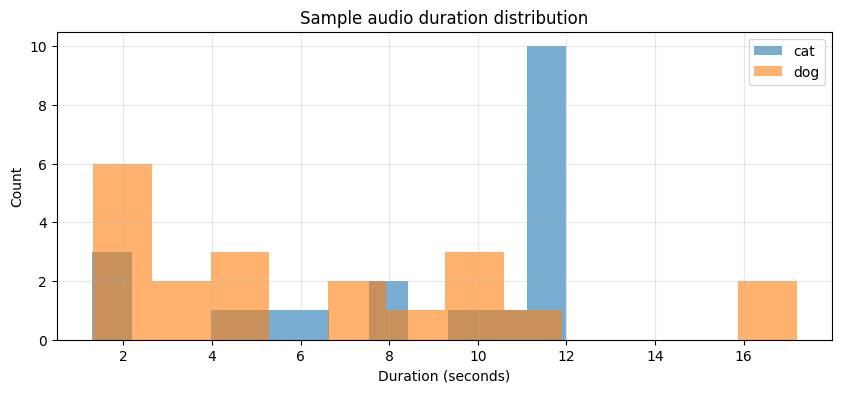

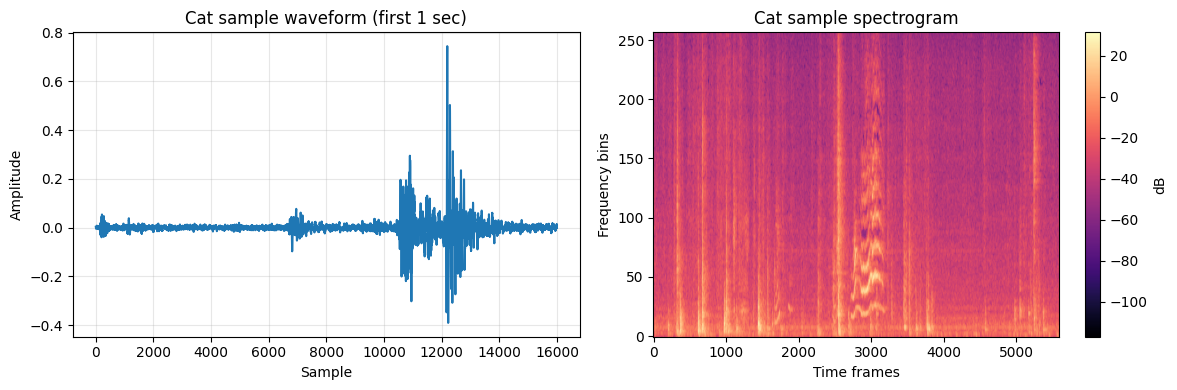

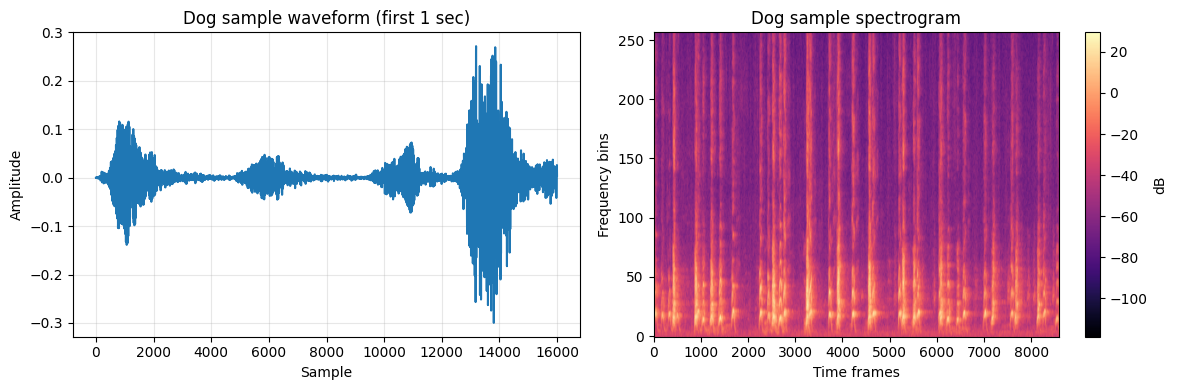

In [18]:
import glob

cat_files = sorted(glob.glob(os.path.join('cats_dogs', 'train', 'cat', '*.wav')))
dog_files = sorted(glob.glob(os.path.join('cats_dogs', 'train', 'dog', '*.wav')))
print('Cat files found:', len(cat_files))
print('Dog files found:', len(dog_files))

sample_durations = []
for file_path, label in [(cat_files[0], 'Cat'), (dog_files[0], 'Dog')]:
    wav, _ = librosa.load(file_path, sr=16000, mono=True)
    sample_durations.append((label, len(wav) / 16000.0))

print('Sample audio durations (seconds):', sample_durations)

plt.figure(figsize=(10, 4))
plt.hist([len(librosa.load(p, sr=16000, mono=True)[0]) / 16000.0 for p in cat_files[:20]], bins=12, alpha=0.6, label='cat')
plt.hist([len(librosa.load(p, sr=16000, mono=True)[0]) / 16000.0 for p in dog_files[:20]], bins=12, alpha=0.6, label='dog')
plt.title('Sample audio duration distribution')
plt.xlabel('Duration (seconds)')
plt.ylabel('Count')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

for file_path, label in [(cat_files[0], 'Cat sample'), (dog_files[0], 'Dog sample')]:
    wav, _ = librosa.load(file_path, sr=16000, mono=True)
    spec = np.abs(tf.signal.stft(wav, frame_length=320, frame_step=32).numpy()).T

    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(wav[:16000])
    plt.title(f'{label} waveform (first 1 sec)')
    plt.xlabel('Sample')
    plt.ylabel('Amplitude')
    plt.grid(alpha=0.3)

    plt.subplot(1, 2, 2)
    plt.imshow(20 * np.log10(spec + 1e-6), aspect='auto', origin='lower', cmap='magma')
    plt.title(f'{label} spectrogram')
    plt.xlabel('Time frames')
    plt.ylabel('Frequency bins')
    plt.colorbar(label='dB')
    plt.tight_layout()
    plt.show()


## Part 1: Fixed-Length Model (2D CNN)
For the CNN, we need a strict, constant input shape. We will pad or truncate all audio files to exactly 5 seconds (80,000 samples at 16kHz). Then, we convert them to spectrograms.

In [19]:
def load_wav_16k_mono(file_path):
    if hasattr(file_path, 'item'):
        file_path = file_path.item()
    if isinstance(file_path, bytes):
        file_path = file_path.decode('utf-8')
    wav, _ = librosa.load(file_path, sr=16000, mono=True)
    return wav.astype(np.float32)


def preprocess_fixed(file_path, data_label): 
    wav = tf.numpy_function(load_wav_16k_mono, [file_path], tf.float32)
    wav.set_shape([None])
    
    # Фіксована довжина: 5 секунд * 16000 = 80000 семплів
    wav = wav[:80000]  
    zero_padding = tf.zeros([80000] - tf.shape(wav), dtype=tf.float32)
    wav = tf.concat([zero_padding, wav], axis=0)

    # Спектрограма
    spectrogram_wav = tf.signal.stft(wav, frame_length=320, frame_step=32)
    spectrogram_wav = tf.abs(spectrogram_wav)
    spectrogram_wav = tf.expand_dims(spectrogram_wav, axis=2)  # Додаємо канал
    
    return spectrogram_wav, data_label

# Будуємо пайплайн без батчування перед розподілом, щоб take/skip працювали по зразках.
fixed_data = data.map(preprocess_fixed, num_parallel_calls=tf.data.AUTOTUNE)
fixed_data = fixed_data.cache().shuffle(buffer_size=1000)

total_examples = len(cat_files) + len(dog_files)
train_examples = int(total_examples * 0.7)

train_fixed = fixed_data.take(train_examples).batch(16).prefetch(tf.data.AUTOTUNE)
test_fixed = fixed_data.skip(train_examples).batch(16).prefetch(tf.data.AUTOTUNE)


In [20]:
model_cnn = Sequential([
    Input(shape=(2491, 257, 1)),
    Conv2D(16, (3,3), strides=(3,3), activation='relu'),
    MaxPool2D((2,2)),
    Conv2D(32, (3,3), strides=(3,3), activation='relu'),
    MaxPool2D((2,2)),
    Flatten(),
    Dense(64, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

model_cnn.compile(optimizer='adam', 
                  loss='binary_crossentropy', 
                  metrics=['accuracy', tf.keras.metrics.Recall(), tf.keras.metrics.Precision()])

model_cnn.summary()

print("\n--- Training Fixed-Length Model (CNN) ---")
history_cnn = model_cnn.fit(train_fixed, epochs=8, validation_data=test_fixed)

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 830, 85, 16)    │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 415, 42, 16)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 138, 14, 32)    │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 69, 7, 32)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 15456)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │       989,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 994,113 (3.79 MB)

 Trainable params: 994,113 (3.79 MB)

 Non-trainable params: 0 (0.00 B)


--- Training Fixed-Length Model (CNN) ---
Epoch 1/8
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 67ms/step - accuracy: 0.6259 - loss: 0.7491 - precision_2: 0.6667 - recall_2: 0.7059 - val_accuracy: 0.8889 - val_loss: 0.3956 - val_precision_2: 0.8864 - val_recall_2: 0.9512
Epoch 2/8
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 51ms/step - accuracy: 0.8503 - loss: 0.4571 - precision_2: 0.8384 - recall_2: 0.9326 - val_accuracy: 0.9365 - val_loss: 0.3041 - val_precision_2: 0.9286 - val_recall_2: 0.9750
Epoch 3/8
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 50ms/step - accuracy: 0.8503 - loss: 0.4074 - precision_2: 0.8352 - recall_2: 0.9157 - val_accuracy: 0.8571 - val_loss: 0.3531 - val_precision_2: 0.9211 - val_recall_2: 0.8537
Epoch 4/8
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.8776 - loss: 0.3584 - precision_2: 0.8868 - recall_2: 0.9400 - val_accuracy: 0.9206 - val_loss: 0.3706 - val_precision_2: 0.8864 - val_recall_2: 1.0000
Epoch 5/8
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 50ms/step - accuracy: 0.9252 - loss: 0.2143 - precisi

Fixed-length CNN test metrics: {'loss': 0.09352293610572815, 'compile_metrics': 0.9841269850730896}


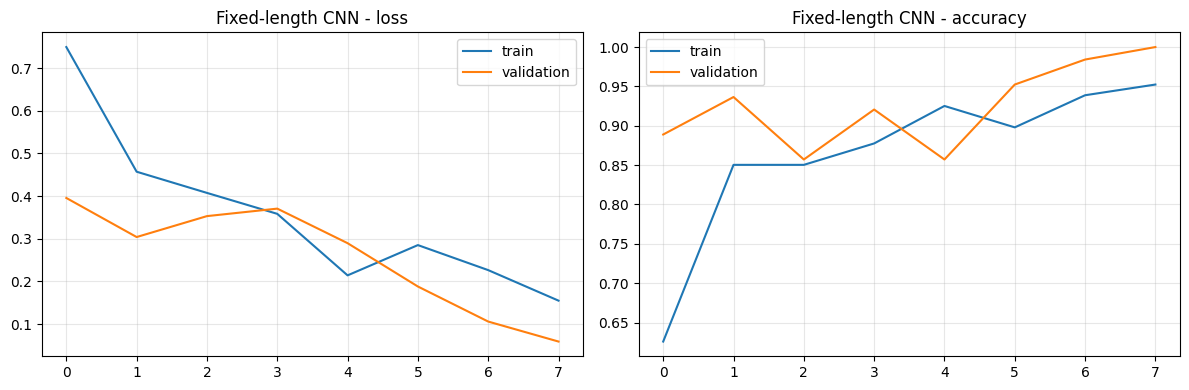

In [21]:
cnn_metrics = model_cnn.evaluate(test_fixed, verbose=0)
print('Fixed-length CNN test metrics:', dict(zip(model_cnn.metrics_names, cnn_metrics)))
plot_history(history_cnn, 'Fixed-length CNN')


## Part 2: Variable-Length Model (LSTM with Masking)
Now, we build an architecture that accepts dynamic sequence lengths. We won't truncate the audio to a fixed length. Instead, we compute the spectrogram of the actual length, pad the batch to the longest sequence in that specific batch, and use a `Masking` layer so the LSTM ignores the padded zeros.

In [22]:
def preprocess_variable(file_path, data_label): 
    wav = tf.numpy_function(load_wav_16k_mono, [file_path], tf.float32)
    wav.set_shape([None])

    # Спектрограма без фіксованого обрізання/паддингу самого аудіо
    spectrogram_wav = tf.signal.stft(wav, frame_length=320, frame_step=32)
    spectrogram_wav = tf.abs(spectrogram_wav)
    
    return spectrogram_wav, data_label

variable_data = data.map(preprocess_variable, num_parallel_calls=tf.data.AUTOTUNE)
variable_data = variable_data.cache().shuffle(buffer_size=1000)

train_var = variable_data.take(train_examples).padded_batch(16, padded_shapes=([None, 257], [])).prefetch(tf.data.AUTOTUNE)
test_var = variable_data.skip(train_examples).padded_batch(16, padded_shapes=([None, 257], [])).prefetch(tf.data.AUTOTUNE)


In [23]:
model_lstm = Sequential([
    Input(shape=(None, 257)), 
    Masking(mask_value=0.0), 
    LSTM(64, return_sequences=False, dropout=0.2), 
    Dense(32, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

model_lstm.compile(optimizer='adam', 
                   loss='binary_crossentropy', 
                   metrics=['accuracy', tf.keras.metrics.Recall(), tf.keras.metrics.Precision()])

model_lstm.summary()

print("\n--- Training Variable-Length Model (LSTM) ---")
history_lstm = model_lstm.fit(train_var, epochs=8, validation_data=test_var, verbose=2)

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ masking_1 (Masking)             │ (None, None, 257)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        82,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 84,545 (330.25 KB)

 Trainable params: 84,545 (330.25 KB)

 Non-trainable params: 0 (0.00 B)


--- Training Variable-Length Model (LSTM) ---
Epoch 1/8
10/10 - 14s - 1s/step - accuracy: 0.5510 - loss: 0.6947 - precision_3: 0.5978 - recall_3: 0.6548 - val_accuracy: 0.7302 - val_loss: 0.6100 - val_precision_3: 0.6731 - val_recall_3: 1.0000
Epoch 2/8
10/10 - 12s - 1s/step - accuracy: 0.6667 - loss: 0.6176 - precision_3: 0.6471 - recall_3: 0.9167 - val_accuracy: 0.8571 - val_loss: 0.5175 - val_precision_3: 0.8049 - val_recall_3: 0.9706
Epoch 3/8
10/10 - 12s - 1s/step - accuracy: 0.8095 - loss: 0.5072 - precision_3: 0.8229 - recall_3: 0.8778 - val_accuracy: 0.8254 - val_loss: 0.4908 - val_precision_3: 0.8788 - val_recall_3: 0.8056
Epoch 4/8
10/10 - 11s - 1s/step - accuracy: 0.8367 - loss: 0.4714 - precision_3: 0.8247 - recall_3: 0.9195 - val_accuracy: 0.9206 - val_loss: 0.3036 - val_precision_3: 0.9211 - val_recall_3: 0.9459
Epoch 5/8
10/10 - 11s - 1s/step - accuracy: 0.8707 - loss: 0.3660 - precision_3: 0.8989 - recall_3: 0.8889 - val_accuracy: 0.9365 - val_loss: 0.2428 - val_precis

Variable-length LSTM test metrics: {'loss': 0.2630220651626587, 'compile_metrics': 0.920634925365448}


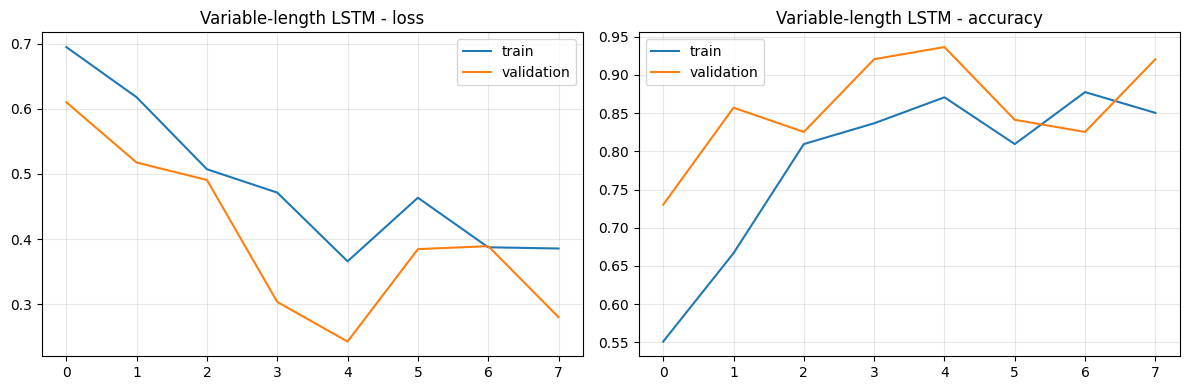

In [24]:
lstm_metrics = model_lstm.evaluate(test_var, verbose=0)
print('Variable-length LSTM test metrics:', dict(zip(model_lstm.metrics_names, lstm_metrics)))
plot_history(history_lstm, 'Variable-length LSTM')


In [25]:
comparison = pd.DataFrame([
    {
        'model': 'Fixed-length CNN',
        'loss': float(cnn_metrics[0]),
        'accuracy': float(cnn_metrics[1]),
        'recall': float(cnn_metrics[2]),
        'precision': float(cnn_metrics[3])
    },
    {
        'model': 'Variable-length LSTM',
        'loss': float(lstm_metrics[0]),
        'accuracy': float(lstm_metrics[1]),
        'recall': float(lstm_metrics[2]),
        'precision': float(lstm_metrics[3])
    }
])

comparison.set_index('model', inplace=True)
print('Final comparison of test results:')
display(comparison)

Final comparison of test results:


,loss,accuracy,recall,precision
model,,,,
Fixed-length CNN,0.093523,0.984127,1.0,0.972222
Variable-length LSTM,0.263022,0.920635,1.0,0.864865


### Mandatory Conclusions

This lab work practically demonstrates the differences between fixed-length and variable-length sequential models in terms of data processing, training dynamics, and predictive performance. By applying **Track C (High-Complexity Data Domains)**, the models were trained on raw audio waveforms converted into spectrograms.

#### 1. Summary of the Work
*   **Fixed-length CNN:** The audio samples were strictly padded or truncated to a consistent 5-second duration. The model learned from a uniform input shape, treating the spectrogram as a 2D image.
*   **Variable-length LSTM:** The audio was processed dynamically without cutting the original temporal length. The data pipeline padded sequences only up to the maximum length within each specific batch, and a `Masking` layer was utilized so the LSTM mathematically ignored the padded zeros.

#### 2. Empirical Results & Dataset Limitations
Based on the final evaluation on the test set, the models achieved the following metrics:
*   **Fixed-length CNN:** Accuracy **98.4%**, Loss 0.094, Precision 97.2%, Recall 100.0%.
*   **Variable-length LSTM:** Accuracy **92.1%**, Loss 0.263, Precision 86.5%, Recall 100.0%.

#### 3. Key Findings & Architectural Insights
*   **CNN Superiority on Spectrograms:** In this specific task, the fixed-length CNN achieved near-perfect results, outperforming the variable-length LSTM across all metrics. While both models achieved a 100% Recall, the LSTM struggled more with false positives (lower precision). This happens because spectrograms are essentially 2D representations of audio, and CNNs are highly optimized to extract local spatial patterns (like harmonic edges and frequency bursts).
*   **LSTM Trade-offs:** The variable-length LSTM offers the massive advantage of architectural flexibility—it naturally handles real-world audio of any duration without discarding data. However, recurrent models process data step-by-step and can sometimes struggle to maintain context over extremely long sequences, whereas CNNs capture features globally through pooling.
*   **Training Speed Comparison:** The CNN model trained significantly faster (taking around **1 second per epoch**). The LSTM was notably slower (taking around **11–14 seconds per epoch**). This difference highlights the sequential nature of recurrent layers, which cannot be parallelized as efficiently across time steps as the spatial convolutions in a CNN.

#### 4. Recommendation
For audio classification tasks where the target sounds are relatively short and can be safely normalized to a standard duration, a **Fixed-length CNN** is highly recommended due to its exceptional accuracy and fast training speed. However, for tasks where audio lengths vary drastically (e.g., speech recognition, continuous monitoring) and temporal flow is critical, the **Variable-length LSTM** remains the superior architectural choice, despite requiring more complex data engineering and longer training times.